In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

print("준비 완료!")

준비 완료!


In [2]:
data = {
    'temp_C':      [200, 250, 300, 350, 400, 450, 500, 550],
    'time_h':      [1,   2,   1,   3,   2,   1,   4,   2  ],
    'hardness_HV': [120, 145, 180, 210, 195, 170, 155, 140],
    'tensile_MPa': [350, 410, 490, 530, 510, 460, 420, 390],
    'sample_id':   ['S01','S02','S03','S04','S05','S06','S07','S08'],
    'temp_range':  ['low','low','low','mid','mid','mid','high','high'],
    'grade':       ['C','C','A','A','A','B','B','C']
}

df = pd.DataFrame(data)
print("Data shape:", df.shape)
df

Data shape: (8, 7)


,temp_C,time_h,hardness_HV,tensile_MPa,sample_id,temp_range,grade
0,200,1,120,350,S01,low,C
1,250,2,145,410,S02,low,C
2,300,1,180,490,S03,low,A
3,350,3,210,530,S04,mid,A
4,400,2,195,510,S05,mid,A
5,450,1,170,460,S06,mid,B
6,500,4,155,420,S07,high,B
7,550,2,140,390,S08,high,C


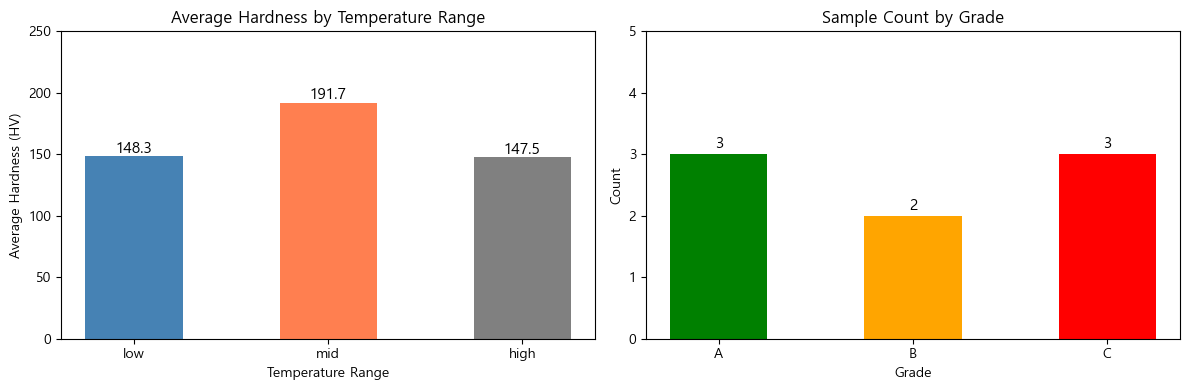

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Graph 1: 온도 구간별 평균 경도 막대그래프
temp_grouped = df.groupby('temp_range')['hardness_HV'].mean()
temp_grouped = temp_grouped.reindex(['low', 'mid', 'high'])  # 순서 정렬

axes[0].bar(temp_grouped.index, temp_grouped.values,
            color=['steelblue', 'coral', 'gray'], width=0.5)
axes[0].set_xlabel('Temperature Range')
axes[0].set_ylabel('Average Hardness (HV)')
axes[0].set_title('Average Hardness by Temperature Range')
axes[0].set_ylim(0, 250)

# 막대 위에 숫자 표시
for i, v in enumerate(temp_grouped.values):
    axes[0].text(i, v + 3, f'{v:.1f}', ha='center', fontsize=11)

# Graph 2: 등급별 샘플 수 막대그래프
grade_count = df['grade'].value_counts().sort_index()

axes[1].bar(grade_count.index, grade_count.values,
            color=['green', 'orange', 'red'], width=0.5)
axes[1].set_xlabel('Grade')
axes[1].set_ylabel('Count')
axes[1].set_title('Sample Count by Grade')
axes[1].set_ylim(0, 5)

for i, v in enumerate(grade_count.values):
    axes[1].text(i, v + 0.1, str(v), ha='center', fontsize=11)

plt.tight_layout()
plt.show()

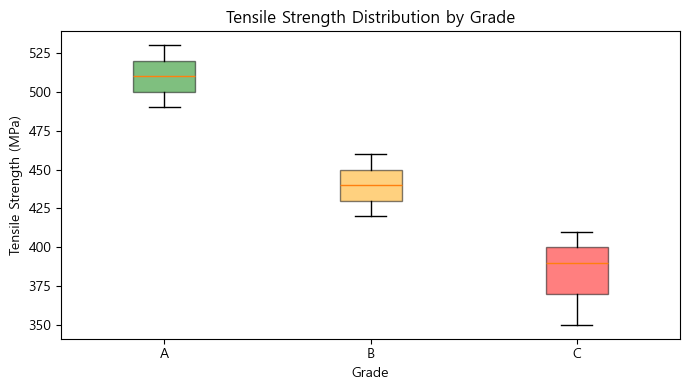

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))

# 등급별 인장강도 분포
grade_data = [df[df['grade'] == g]['tensile_MPa'].values for g in ['A', 'B', 'C']]

bp = ax.boxplot(grade_data, tick_labels=['A', 'B', 'C'], patch_artist=True)

# 색상 설정
colors = ['green', 'orange', 'red']
for patch, color in zip(bp['boxes'], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.5)

ax.set_xlabel('Grade')
ax.set_ylabel('Tensile Strength (MPa)')
ax.set_title('Tensile Strength Distribution by Grade')

plt.tight_layout()
plt.show()

In [5]:
import plotly.express as px
import plotly.graph_objects as go

print("plotly 설치 확인 완료!")

plotly 설치 확인 완료!


In [10]:
import plotly.io as pio
pio.renderers.default = 'iframe'

fig = px.scatter(df,
                 x='temp_C',
                 y='hardness_HV',
                 color='grade',
                 size='tensile_MPa',
                 hover_data=['sample_id', 'time_h', 'tensile_MPa'],
                 title='Temperature vs Hardness (Interactive)',
                 labels={'temp_C': 'Sintering Temperature (°C)',
                         'hardness_HV': 'Hardness (HV)',
                         'grade': 'Grade'})

fig.show()

In [9]:
temp_grouped = df.groupby('temp_range')['hardness_HV'].mean().reset_index()
temp_grouped = temp_grouped.set_index('temp_range').reindex(['low', 'mid', 'high']).reset_index()

fig = px.bar(temp_grouped,
             x='temp_range',
             y='hardness_HV',
             color='temp_range',
             text='hardness_HV',
             title='Average Hardness by Temperature Range (Interactive)',
             labels={'temp_range': 'Temperature Range',
                     'hardness_HV': 'Average Hardness (HV)'})

fig.update_traces(texttemplate='%{text:.1f}', textposition='outside')
fig.show()

PNG 저장 완료!
HTML 저장 완료!


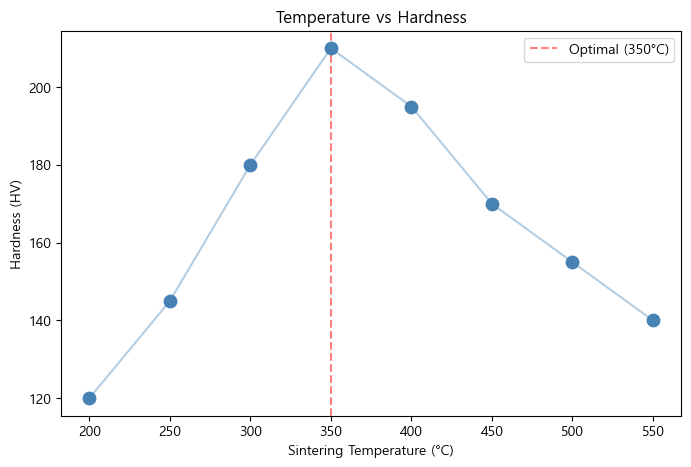

In [11]:
# matplotlib 그래프 PNG로 저장
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(df['temp_C'], df['hardness_HV'],
           color='steelblue', s=80, zorder=5)
ax.plot(df['temp_C'], df['hardness_HV'],
        color='steelblue', alpha=0.4)
ax.set_xlabel('Sintering Temperature (°C)')
ax.set_ylabel('Hardness (HV)')
ax.set_title('Temperature vs Hardness')
ax.axvline(x=350, color='red', linestyle='--', alpha=0.5, label='Optimal (350°C)')
ax.legend()

# PNG 파일로 저장
fig.savefig('temperature_vs_hardness.png', dpi=150, bbox_inches='tight')
print("PNG 저장 완료!")

# plotly 그래프 HTML로 저장
fig2 = px.scatter(df, x='temp_C', y='hardness_HV',
                  color='grade', size='tensile_MPa',
                  title='Temperature vs Hardness (Interactive)')
fig2.write_html('temperature_vs_hardness.html')
print("HTML 저장 완료!")